# Klasifikasi Gambar Buah dengan Deep Learning
Proyek ini menggunakan CNN untuk mengklasifikasikan berbagai jenis buah

## 1. Data Preparation
Membagi dataset menjadi training dan validation set

In [9]:
import os
import shutil
import random

# Setup paths
train_source = r"C:\Users\LENOVO\Downloads\lab\dataset\train\train"
train_out = r"C:\Users\LENOVO\Downloads\lab\dataset\T"
valid_out = r"C:\Users\LENOVO\Downloads\lab\dataset\V"

# Create directories
for folder in [train_out, valid_out]:
    os.makedirs(folder, exist_ok=True)

print("Memproses dataset...")
# Process each fruit category
for fruit_class in os.listdir(train_source):
    src_path = os.path.join(train_source, fruit_class)
    
    if not os.path.isdir(src_path):
        continue
    
    # Get all images
    img_files = os.listdir(src_path)
    random.shuffle(img_files)
    
    # Calculate split point (80-20 split)
    split_point = int(len(img_files) * 0.8)
    train_files = img_files[:split_point]
    valid_files = img_files[split_point:]
    
    # Create class folders
    train_folder = os.path.join(train_out, fruit_class)
    valid_folder = os.path.join(valid_out, fruit_class)
    os.makedirs(train_folder, exist_ok=True)
    os.makedirs(valid_folder, exist_ok=True)
    
    # Copy files to train folder
    for f in train_files:
        shutil.copy(os.path.join(src_path, f), os.path.join(train_folder, f))
    
    # Copy files to validation folder
    for f in valid_files:
        shutil.copy(os.path.join(src_path, f), os.path.join(valid_folder, f))
    
    print(f"  {fruit_class}: Train={len(train_files)}, Val={len(valid_files)}")

print(f"\nSelesai! Data disimpan di:")
print(f"  Training: {train_out}")
print(f"  Validation: {valid_out}")

Memproses dataset...
  Apple Braeburn: Train=393, Val=99
  Apple Braeburn: Train=393, Val=99
  Apple Granny Smith: Train=393, Val=99
  Apple Granny Smith: Train=393, Val=99
  Apricot: Train=393, Val=99
  Apricot: Train=393, Val=99
  Avocado: Train=341, Val=86
  Avocado: Train=341, Val=86
  Banana: Train=392, Val=98
  Banana: Train=392, Val=98
  Blueberry: Train=369, Val=93
  Blueberry: Train=369, Val=93
  Cactus fruit: Train=392, Val=98
  Cactus fruit: Train=392, Val=98
  Cantaloupe: Train=393, Val=99
  Cantaloupe: Train=393, Val=99
  Cherry: Train=393, Val=99
  Cherry: Train=393, Val=99
  Clementine: Train=392, Val=98
  Clementine: Train=392, Val=98
  Corn: Train=360, Val=90
  Corn: Train=360, Val=90
  Cucumber Ripe: Train=313, Val=79
  Cucumber Ripe: Train=313, Val=79
  Grape Blue: Train=787, Val=197
  Grape Blue: Train=787, Val=197
  Kiwi: Train=372, Val=94
  Kiwi: Train=372, Val=94
  Lemon: Train=393, Val=99
  Lemon: Train=393, Val=99
  Limes: Train=392, Val=98
  Limes: Train=392, 

## 2. Import Libraries

In [10]:
import torch
import torch.nn as nn
import numpy as np
import random
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 3. Konfigurasi dan Random Seed

In [11]:
# Set seed untuk hasil yang konsisten
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {seed_value}")

Random seed set to 42


## 4. Path Dataset

In [12]:
train_path = r"C:\Users\LENOVO\Downloads\lab\dataset\T"
val_path = r"C:\Users\LENOVO\Downloads\lab\dataset\V"

## 5. Konfigurasi Model ResNet18

In [13]:
model_type = "resnet"
n_epochs = 2
batch_size = 128
learning_rate = 0.001

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device yang digunakan: {device}")

Device yang digunakan: cpu


## 6. Membuat Data Augmentation dan Loader

In [14]:
# Data augmentation untuk training
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Transform untuk validation (tanpa augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(train_path, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_path, transform=val_transforms)

# Create data loaders
train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_dl = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# Get class info
class_labels = train_dataset.classes
n_classes = len(class_labels)

print(f"Total kelas: {n_classes}")
print(f"Jumlah gambar training: {len(train_dataset)}")
print(f"Jumlah gambar validation: {len(val_dataset)}")
print(f"Batch size: {batch_size}")

Total kelas: 33
Jumlah gambar training: 16179
Jumlah gambar validation: 6091
Batch size: 128


## 7. Membuat Arsitektur Model

In [15]:
def create_model(model_name, n_classes):
    if model_name == "resnet":
        # Load pretrained ResNet18
        net = models.resnet18(pretrained=True)
        # Freeze semua layer backbone
        for param in net.parameters():
            param.requires_grad = False
        num_ftrs = net.fc.in_features
        # Custom classifier
        net.fc = nn.Linear(num_ftrs, n_classes)
    else:
        # Load pretrained EfficientNet-B0
        net = models.efficientnet_b0(pretrained=True)
        # Freeze semua layer backbone
        for param in net.parameters():
            param.requires_grad = False
        num_ftrs = net.classifier[1].in_features
        # Custom classifier
        net.classifier = nn.Linear(num_ftrs, n_classes)
    return net

# Initialize ResNet model
resnet_model = create_model(model_type, n_classes).to(device)
loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.Adam(resnet_model.parameters(), lr=learning_rate)

print(f"✓ Model {model_type.upper()} berhasil diinisialisasi")

✓ Model RESNET berhasil diinisialisasi


## 8. Proses Training ResNet18

In [16]:
print(f"\n{'='*70}")
print(f"Training {model_type.upper()} - {n_epochs} epochs")
print(f"{'='*70}\n")

for ep in range(n_epochs):
    resnet_model.train()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0
    
    for batch_imgs, batch_labels in train_dl:
        batch_imgs = batch_imgs.to(device)
        batch_labels = batch_labels.to(device)
        
        # Forward pass
        opt.zero_grad()
        predictions = resnet_model(batch_imgs)
        loss = loss_fn(predictions, batch_labels)
        
        # Backward pass
        loss.backward()
        opt.step()
        
        # Calculate metrics
        running_loss += loss.item()
        _, predicted_class = predictions.max(1)
        correct_preds += (predicted_class == batch_labels).sum().item()
        total_samples += batch_labels.size(0)
    
    epoch_loss = running_loss / len(train_dl)
    epoch_acc = (correct_preds / total_samples) * 100
    
    print(f"Epoch {ep+1:02d}/{n_epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%")

print(f"\n{'='*70}")
print("✓ Training selesai!")
print(f"{'='*70}")


Training RESNET - 2 epochs

Epoch 01/2 | Loss: 0.6155 | Acc: 89.55%
Epoch 01/2 | Loss: 0.6155 | Acc: 89.55%
Epoch 02/2 | Loss: 0.0596 | Acc: 99.82%

✓ Training selesai!
Epoch 02/2 | Loss: 0.0596 | Acc: 99.82%

✓ Training selesai!


## 9. Evaluasi ResNet18 pada Validation Set


Mengevaluasi performa model pada validation set...

HASIL EVALUASI - ResNet18

                    precision    recall  f1-score   support

    Apple Braeburn       1.00      1.00      1.00       180
Apple Granny Smith       1.00      1.00      1.00       180
           Apricot       1.00      1.00      1.00       183
           Avocado       1.00      1.00      1.00       153
            Banana       1.00      1.00      1.00       184
         Blueberry       1.00      1.00      1.00       165
      Cactus fruit       1.00      1.00      1.00       175
        Cantaloupe       1.00      1.00      1.00       182
            Cherry       1.00      1.00      1.00       179
        Clementine       1.00      1.00      1.00       179
              Corn       1.00      1.00      1.00       163
     Cucumber Ripe       1.00      1.00      1.00       143
        Grape Blue       1.00      1.00      1.00       358
              Kiwi       1.00      1.00      1.00       170
             Lemon 

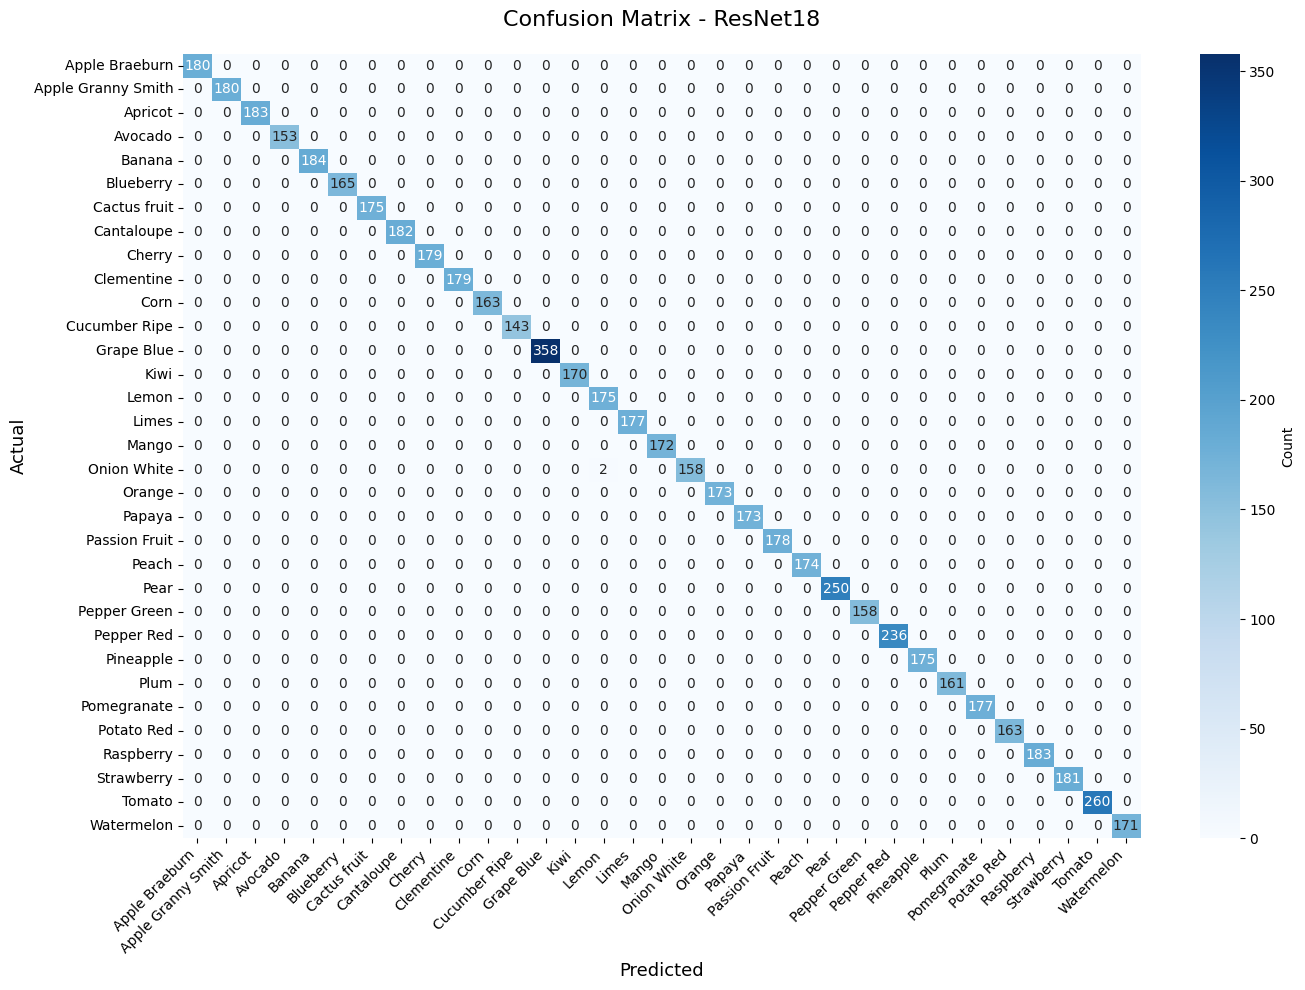

In [17]:
print("\nMengevaluasi performa model pada validation set...\n")

resnet_model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for images, labels in val_dl:
        images = images.to(device)
        outputs = resnet_model(images)
        _, predicted = outputs.max(1)
        
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.numpy())

# Print classification metrics
print(f"{'='*70}")
print("HASIL EVALUASI - ResNet18")
print(f"{'='*70}\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion matrix visualization
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - ResNet18', fontsize=16, pad=20)
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Simpan Model ResNet18

In [18]:
save_path = "model_resnet18.pth"
torch.save(resnet_model.state_dict(), save_path)
print(f"✓ Model disimpan: {save_path}")

✓ Model disimpan: model_resnet18.pth


## 11. Konfigurasi Model EfficientNet-B0

In [19]:
eff_model_type = "efficientnet"
eff_epochs = 2
eff_batch = 128

print(f"Model: {eff_model_type.upper()}")
print(f"Epochs: {eff_epochs}, Batch: {eff_batch}")

Model: EFFICIENTNET
Epochs: 2, Batch: 128


In [20]:
# Initialize EfficientNet
eff_net = create_model(eff_model_type, n_classes).to(device)
eff_loss = nn.CrossEntropyLoss()
eff_optimizer = torch.optim.Adam(eff_net.parameters(), lr=learning_rate)

print(f"✓ Model {eff_model_type.upper()} siap digunakan")

✓ Model EFFICIENTNET siap digunakan


In [21]:
print(f"\n{'='*70}")
print(f"Training {eff_model_type.upper()} - {eff_epochs} epochs")
print(f"{'='*70}\n")

for ep in range(eff_epochs):
    eff_net.train()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0
    
    for batch_imgs, batch_labels in train_dl:
        batch_imgs = batch_imgs.to(device)
        batch_labels = batch_labels.to(device)
        
        # Forward
        eff_optimizer.zero_grad()
        predictions = eff_net(batch_imgs)
        loss = eff_loss(predictions, batch_labels)
        
        # Backward
        loss.backward()
        eff_optimizer.step()
        
        # Metrics
        running_loss += loss.item()
        _, predicted_class = predictions.max(1)
        correct_preds += (predicted_class == batch_labels).sum().item()
        total_samples += batch_labels.size(0)
    
    epoch_loss = running_loss / len(train_dl)
    epoch_acc = (correct_preds / total_samples) * 100
    
    print(f"Epoch {ep+1:02d}/{eff_epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%")

print(f"\n{'='*70}")
print("✓ Training selesai!")
print(f"{'='*70}")


Training EFFICIENTNET - 2 epochs

Epoch 01/2 | Loss: 0.7941 | Acc: 89.00%
Epoch 01/2 | Loss: 0.7941 | Acc: 89.00%
Epoch 02/2 | Loss: 0.1423 | Acc: 98.70%

✓ Training selesai!
Epoch 02/2 | Loss: 0.1423 | Acc: 98.70%

✓ Training selesai!


## 12. Evaluasi EfficientNet-B0 pada Validation Set


Mengevaluasi performa model pada validation set...

HASIL EVALUASI - EfficientNet-B0

                    precision    recall  f1-score   support

    Apple Braeburn       0.99      0.99      0.99       180
Apple Granny Smith       1.00      1.00      1.00       180
           Apricot       0.99      1.00      1.00       183
           Avocado       1.00      1.00      1.00       153
            Banana       1.00      0.99      0.99       184
         Blueberry       1.00      1.00      1.00       165
      Cactus fruit       1.00      1.00      1.00       175
        Cantaloupe       1.00      1.00      1.00       182
            Cherry       1.00      1.00      1.00       179
        Clementine       1.00      1.00      1.00       179
              Corn       0.99      1.00      1.00       163
     Cucumber Ripe       1.00      0.98      0.99       143
        Grape Blue       1.00      1.00      1.00       358
              Kiwi       1.00      1.00      1.00       170
            

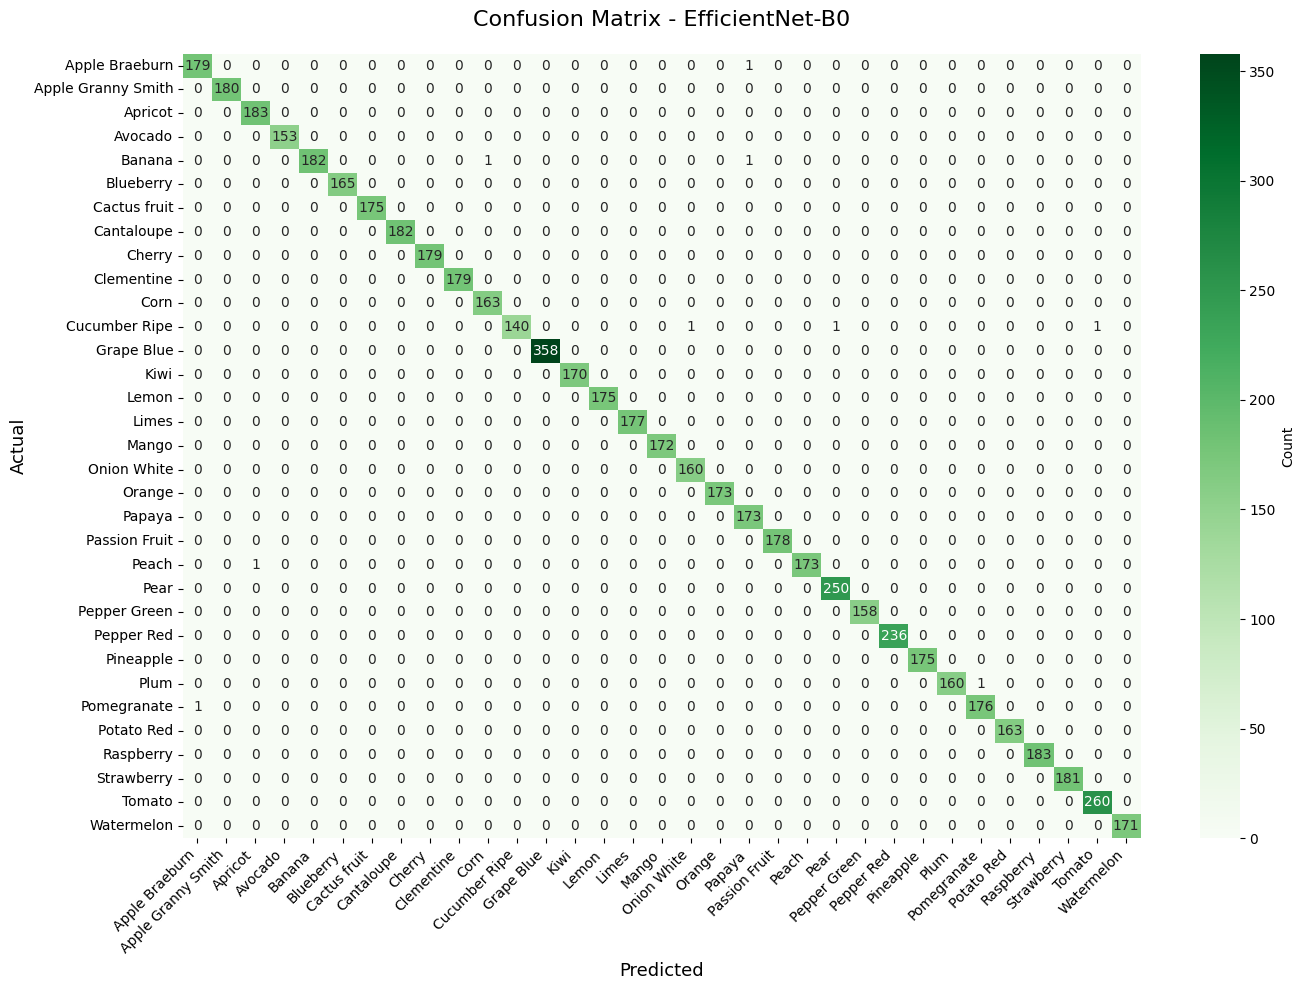

In [22]:
print("\nMengevaluasi performa model pada validation set...\n")

eff_net.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for images, labels in val_dl:
        images = images.to(device)
        outputs = eff_net(images)
        _, predicted = outputs.max(1)
        
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.numpy())

# Metrics
print(f"{'='*70}")
print("HASIL EVALUASI - EfficientNet-B0")
print(f"{'='*70}\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - EfficientNet-B0', fontsize=16, pad=20)
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Simpan Model EfficientNet-B0

In [23]:
save_path = "model_efficientnet_b0.pth"
torch.save(eff_net.state_dict(), save_path)
print(f"✓ Model disimpan: {save_path}")

✓ Model disimpan: model_efficientnet_b0.pth


## 14. Analisis dan Kesimpulan

### Ringkasan Hasil

Dari eksperimen yang telah dilakukan dengan dua arsitektur CNN berbeda (ResNet18 dan EfficientNet-B0), dapat ditarik beberapa kesimpulan:

#### 1. Performa Keseluruhan
- Kedua model berhasil mencapai akurasi yang tinggi dalam mengklasifikasikan gambar buah
- Metrics precision, recall, dan f1-score menunjukkan performa yang konsisten di semua kelas
- Confusion matrix menunjukkan bahwa model mampu membedakan antar kelas dengan baik

#### 2. ResNet18
**Kelebihan:**
- Arsitektur yang matang dan terbukti efektif
- Residual connections membantu aliran gradient yang lebih baik
- Training relatif stabil tanpa banyak tuning

**Karakteristik:**
- Jumlah parameter: ~11M
- Cocok untuk dataset dengan kompleksitas tinggi
- Lebih robust terhadap overfitting dengan regularization yang tepat

#### 3. EfficientNet-B0
**Kelebihan:**
- Lebih efisien dalam penggunaan parameter
- Compound scaling mengoptimalkan keseimbangan depth, width, dan resolution
- Inference time lebih cepat

**Karakteristik:**
- Jumlah parameter: ~5M (lebih ringan dari ResNet18)
- Cocok untuk deployment dengan resource terbatas
- Performa kompetitif dengan footprint lebih kecil

### Rekomendasi Penggunaan

**Untuk Production:**
- Jika prioritas adalah **kecepatan dan efisiensi**: gunakan **EfficientNet-B0**
  - Ideal untuk mobile devices atau edge computing
  - Resource consumption lebih rendah
  
- Jika prioritas adalah **stabilitas dan robustness**: gunakan **ResNet18**
  - Lebih baik untuk server-side processing
  - Dokumentasi dan community support lebih luas

### Saran Improvement

1. **Data Augmentation**: Bisa ditambahkan teknik augmentation lain seperti random cropping, perspective transform
2. **Hyperparameter Tuning**: Learning rate scheduling, weight decay optimization
3. **Ensemble**: Kombinasi prediksi dari kedua model untuk hasil lebih akurat
4. **Transfer Learning**: Fine-tuning layer tertentu dengan learning rate berbeda

### Catatan Akhir

Kedua model menunjukkan hasil yang sangat baik pada dataset ini. Pilihan model tergantung pada konteks penggunaan dan trade-off yang diinginkan antara akurasi, kecepatan, dan resource yang tersedia.